## Import Packages


In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',100)

## Loading data

In [9]:
train=pd.read_pickle('../data/train_engineered.pkl')


In [10]:
test=pd.read_pickle('../data/train_engineered.pkl')

In [11]:
train.shape

(590540, 453)

In [12]:
test.shape

(590540, 453)

## Baseline Features for Analysis 

In [13]:
baseline_features = [
    "TransactionAmt",
    "TransactionAmt_log",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "P_emaildomain_group",
    "R_emaildomain_group",
    "P_emaildomain_suffix",
    "R_emaildomain_suffix",
    "match_email",
    "browser_group",
    "os_group",
    "DeviceType",
    "C1",
    "C2",
    "C13",
    "D1",
    "D10",
    "D15",
    "TransactionAmt_to_mean_card1",
    "TransactionAmt_to_std_card1",
    "TransactionAmt_to_mean_card4",
    "TransactionAmt_to_std_card4"
]

## Dependent & Independent Variables

In [14]:
X = train[baseline_features].copy()
y = train['isFraud'].copy()

## Encode categorical columns

In [15]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

## Impute missing values

In [16]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(imputer.fit_transform(X),columns=X.columns)

## Train-Validation-Test split

In [17]:
#First split: 60% train and 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X_imputed, y, test_size=0.4, random_state=42, stratify=y)

X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


print(f'X Train Data: {X_train.shape}')
print(f'X Validation Data: {X_valid.shape}')
print(f'X Test Data: {X_test.shape}')

print("\n Train Distribution")
print(y_train.value_counts(normalize=True)*100)
print("\n Validation Distribution")
print(y_valid.value_counts(normalize=True)*100)
print("\n Test Distribution")
print(y_test.value_counts(normalize=True)*100)

X Train Data: (354324, 31)
X Validation Data: (118108, 31)
X Test Data: (118108, 31)

 Train Distribution
isFraud
0    96.500943
1     3.499057
Name: proportion, dtype: float64

 Validation Distribution
isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64

 Test Distribution
isFraud
0    96.501507
1     3.498493
Name: proportion, dtype: float64


## Evaluation Function 

In [18]:
model_results = []

def evaluate_model(model_name, model, X_data, y_data, dataset_name="Validation"):
    
    y_pred = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_data)[:, 1]
        roc_auc = roc_auc_score(y_data, y_proba)
    else:
        roc_auc = np.nan

    accuracy = accuracy_score(y_data, y_pred)
    precision = precision_score(y_data, y_pred)
    recall = recall_score(y_data, y_pred)
    f1 = f1_score(y_data, y_pred)

    print(f"Model: {model_name}")
    print(f"Dataset: {dataset_name}")
    print("=" * 40)
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print(f"ROC AUC: {roc_auc}")

    print("\nClassification Report:")
    print(classification_report(y_data, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_data, y_pred)
    plt.title(f"Confusion Matrix - {model_name} ({dataset_name})")
    plt.show()

    model_results.append({
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

## XGBoost Starter Model

In [19]:
xgb_model=XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, 
                        eval_metric='logloss', n_jobs=-1,random_state=-1)
xgb_model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Model: XGBosst Classification Starter
Dataset: Validation
Accuracy: 0.9761912825549497
Precision: 0.885131195335277
Recall: 0.3672876844906847
F1 Score: 0.5191518467852257
ROC AUC: 0.9201286697458655

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.89      0.37      0.52      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.68      0.75    118108
weighted avg       0.97      0.98      0.97    118108



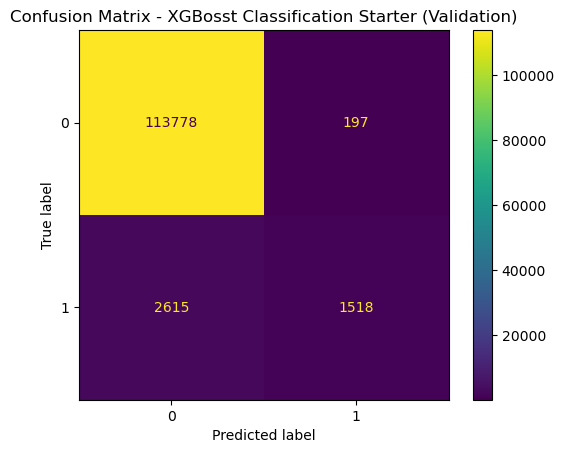

In [20]:
evaluate_model("XGBosst Classification Starter", xgb_model, X_valid, y_valid)

## XGBoost GridSearchCV

In [21]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.08],
    "subsample": [0.5, 0.8],
    "colsample_bytree": [0.5, 0.8]
}

In [22]:
xgb_grid = GridSearchCV(estimator = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
                        param_grid = xgb_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=2)

xgb_grid.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.5, 0.8], 'learning_rate': [0.05, 0.08], 'max_depth': [3, 5], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


[CV] END colsample_bytree=0.5, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.5s
[CV] END colsample_bytree=0.5, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.5; total time=   3.6s
[CV] END colsample_bytree=0.5, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.5, learning_rate=0.08, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.9s
[CV] END colsample_bytree=0.5, learning_rate=0.08, max_depth=5, n_estimators=100, subsample=0.5; total time=   2.6s
[CV] END colsample_bytree=0.5, learning_rate=0.08, max_depth=5, n_estimators=200, subsample=0.5; total time=   4.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.5; total time=   2.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estima

In [23]:
print(f'Best XGBoost Parameters \n {xgb_grid.best_params_}')
print(f'Best XGBoost CV ROC AUC \n {xgb_grid.best_score_}')

Best XGBoost Parameters 
 {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost CV ROC AUC 
 0.9036942197910033


Model: XGB Classifier Tuned
Dataset: Validation
Accuracy: 0.9752006637992346
Precision: 0.868421052631579
Recall: 0.3433341398499879
F1 Score: 0.4921102826426218
ROC AUC: 0.9067102787142175

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.87      0.34      0.49      4133

    accuracy                           0.98    118108
   macro avg       0.92      0.67      0.74    118108
weighted avg       0.97      0.98      0.97    118108



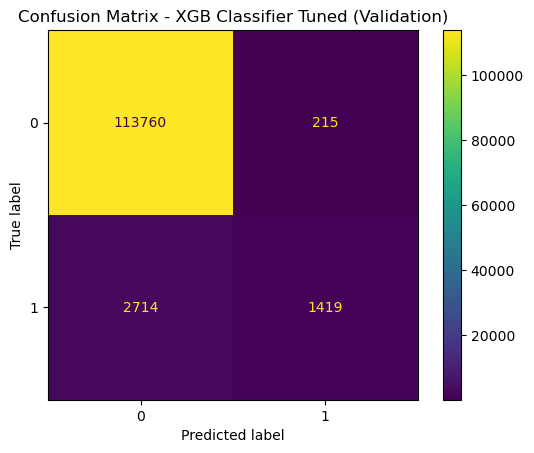

In [25]:
best_xgb_model = xgb_grid.best_estimator_


evaluate_model('XGB Classifier Tuned', best_xgb_model, X_valid, y_valid)